In [1]:
import rasterio

# Path to your GeoTIFF file
geotiff_file = '/home/pratush/Downloads/gdpHiRes.tif'

# Open the GeoTIFF file
with rasterio.open(geotiff_file) as dataset:
    # Get metadata
    metadata = dataset.meta

    # Get CRS (Coordinate Reference System)
    crs = dataset.crs

    # Get image dimensions (width and height)
    width = dataset.width
    height = dataset.height

    # Get transformation parameters (geotransform)
    geotransform = dataset.transform

# Print metadata
print("Metadata:")
print(metadata)

# Print CRS
print("\nCoordinate Reference System (CRS):")
print(crs)

# Print image dimensions
print("\nImage Dimensions:")
print("Width:", width)
print("Height:", height)

# Print geotransformation parameters
print("\nGeotransformation Parameters:")
print("Affine Transformation Matrix:\n\n", geotransform)


Metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': 0.0, 'width': 1440, 'height': 720, 'count': 1, 'crs': CRS.from_epsg(4326), 'transform': Affine(0.25, 0.0, -180.0,
       0.0, -0.24117379166666666, 83.64513)}

Coordinate Reference System (CRS):
EPSG:4326

Image Dimensions:
Width: 1440
Height: 720

Geotransformation Parameters:
Affine Transformation Matrix:

 | 0.25, 0.00,-180.00|
| 0.00,-0.24, 83.65|
| 0.00, 0.00, 1.00|


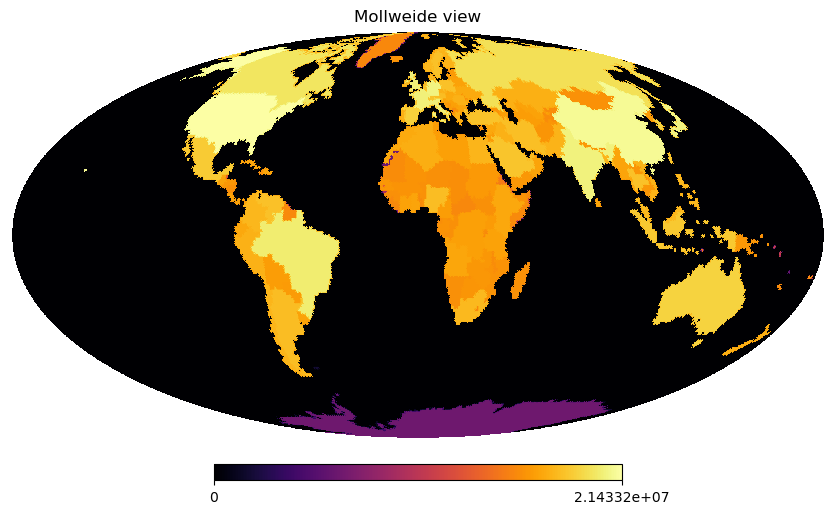

In [2]:
import tifffile as tiff
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
##---------Read the tif file---------##
image = tiff.imread(geotiff_file)
image_array = np.array(image)


#----------Define the spherical coordinates----------#
theta = np.linspace(np.radians(0), np.radians(180), num=image_array.shape[0],endpoint=False)
phi = np.linspace(-np.radians(180), np.radians(180), num=image_array.shape[1],endpoint=False)

#---------- Set angular resolution----------#
nside = 128

##--------Make empty healpix mask and pixel values vector--------##
healpix_map = np.zeros(hp.nside2npix(nside), dtype=np.double)
pixel_counts = np.zeros(hp.nside2npix(nside), dtype=int)


for i in range(len(theta)):
    for j in range(len(phi)):
        pixel = hp.ang2pix(nside, theta[i], phi[j])
        healpix_map[pixel] += image_array[i, j]
        pixel_counts[pixel] += 1

#--------Average value of each pixel--------#
healpix_map[pixel_counts>0] /= pixel_counts[pixel_counts>0 ]


hp.mollview(healpix_map, cmap="inferno", xsize=3000, flip="geo", norm="hist")
plt.show()

In [6]:
healpix_map/=np.max(healpix_map)

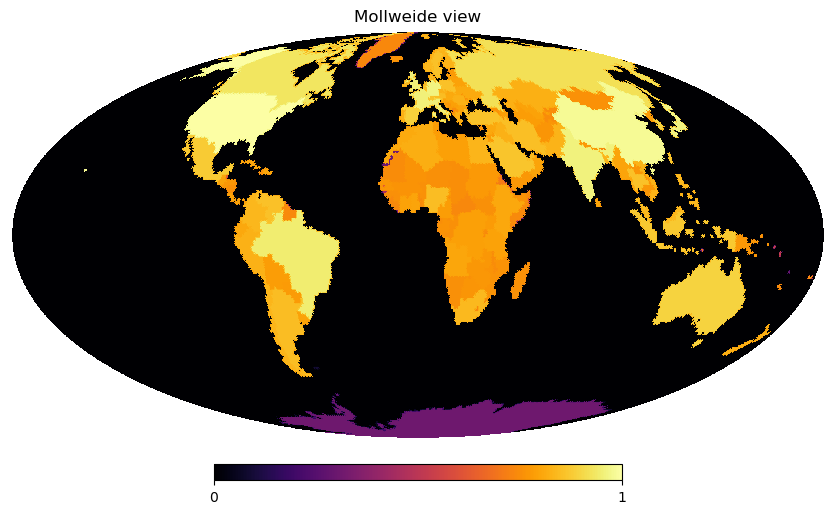

In [7]:
hp.mollview(healpix_map, cmap="inferno", xsize=3000, flip="geo", norm="hist")
plt.show()